In [1]:
import os, random, time, math, copy, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

if os.path.basename(os.getcwd()) != 'Homework_4' and os.path.isdir('Homework_4'):
    os.chdir('Homework_4')
print('current folder:', os.getcwd())

# GOOD_FAST settings for Problem 2.
parallel_cpu_mode = True
if parallel_cpu_mode and device.type == 'cpu':
    torch.set_num_threads(2)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass
print('torch threads:', torch.get_num_threads())

# This is a better quick mode than the first run: still fast, but less undertrained.
fast_run = True
epochs = 25 if parallel_cpu_mode else (12 if fast_run else 25)
batch_size = 128
learning_rate = 0.0035
weight_decay = 5e-5
dropout = 0.08
max_text_chars = 120000 if parallel_cpu_mode else (220000 if fast_run else None)
max_batches_per_epoch = 55 if parallel_cpu_mode else (180 if fast_run else None)
max_val_batches = 20 if parallel_cpu_mode else (60 if fast_run else None)

results_folder = 'Results_Problem_2'
os.makedirs(results_folder, exist_ok=True)

print('*** PROBLEM 2 GOOD_FAST SETTINGS ARE RUNNING ***')
print('parallel_cpu_mode:', parallel_cpu_mode)
print('fast_run:', fast_run)
print('epochs:', epochs)
print('batch_size:', batch_size)
print('max_text_chars:', max_text_chars)
print('max_batches_per_epoch:', max_batches_per_epoch)
print('max_val_batches:', max_val_batches)

device: cpu
current folder: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Homework_4
torch threads: 2
*** PROBLEM 2 GOOD_FAST SETTINGS ARE RUNNING ***
parallel_cpu_mode: True
fast_run: True
epochs: 25
batch_size: 128
max_text_chars: 120000
max_batches_per_epoch: 55
max_val_batches: 20


In [2]:
# Professor style Tiny Shakespeare loader, same idea as Homework 2.
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
data_file = 'tinyshakespeare.txt'

if os.path.exists(data_file):
    with open(data_file, 'r', encoding='utf-8') as f:
        text = f.read()
else:
    try:
        import requests
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text = response.text
    except Exception:
        import urllib.request
        with urllib.request.urlopen(url, timeout=30) as response:
            text = response.read().decode('utf-8')
    with open(data_file, 'w', encoding='utf-8') as f:
        f.write(text)

if max_text_chars is not None:
    text = text[:max_text_chars]

chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in text]

print('Text length:', len(text))
print('Vocabulary size:', len(chars))
print('First 500 chars:')
print(text[:500])

Text length: 120000
Vocabulary size: 61
First 500 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
class CharDataset(Dataset):
    def __init__(self, encoded_text, sequence_length):
        self.encoded_text = encoded_text
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_text) - self.sequence_length

    def __getitem__(self, index):
        seq = self.encoded_text[index:index+self.sequence_length]
        target = self.encoded_text[index+self.sequence_length]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


def get_loaders(sequence_length):
    dataset = CharDataset(encoded_text, sequence_length)
    train_size = int(len(dataset) * 0.8)
    val_size = len(dataset) - train_size
    gen = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=gen)
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)
    return train_loader, val_loader

train_loader, val_loader = get_loaders(20)
print('train batches:', len(train_loader), 'val batches:', len(val_loader))

train batches: 750 val batches: 188


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('encoding', encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)]


class SimpleTransformerBlock(nn.Module):
    def __init__(self, hidden_size, nhead=2, dropout=0.1):
        super(SimpleTransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(hidden_size, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x, need_weights=False)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class ShakespeareTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size=64, num_layers=2, nhead=2, dropout=0.1):
        super(ShakespeareTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(hidden_size, nhead, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        output = self.embedding(x)
        output = self.pos_encoder(output)
        for block in self.blocks:
            output = block(output)
        output = self.dropout(output[:, -1, :])
        output = self.fc(output)
        return output


def get_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return get_params(model) * 4 / (1024 ** 2)


def rough_complexity(seq_length, hidden_size, num_layers):
    return num_layers * ((2 * seq_length * seq_length * hidden_size) + (2 * seq_length * hidden_size * hidden_size))


def top_k_accuracy(output, target, k=3):
    _, pred = output.topk(k, dim=1)
    correct = pred.eq(target.view(-1, 1).expand_as(pred))
    return correct.any(dim=1).sum().item()

In [5]:
def evaluate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct1 = 0
    correct3 = 0
    correct5 = 0
    total = 0
    batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct1 += (pred == y).sum().item()
            correct3 += top_k_accuracy(out, y, k=3)
            correct5 += top_k_accuracy(out, y, k=5)
            total += y.size(0)
            batches += 1
            if max_val_batches is not None and batches >= max_val_batches:
                break
    return total_loss / total, correct1 / total, correct3 / total, correct5 / total


def train_model(config):
    print('\nRUNNING:', config)
    train_loader, val_loader = get_loaders(config['seq_length'])
    model = ShakespeareTransformer(
        vocab_size=len(chars),
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        nhead=config['nhead'],
        dropout=config.get('dropout', dropout)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-5)

    train_losses = []
    val_losses = []
    val_accs = []
    val_top3_accs = []
    val_top5_accs = []
    best_top1 = 0
    best_top3 = 0
    best_top5 = 0
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        total = 0
        batches = 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            total += y.size(0)
            batches += 1
            if max_batches_per_epoch is not None and batches >= max_batches_per_epoch:
                break

        train_loss = running_loss / total
        val_loss, val_acc, val_top3, val_top5 = evaluate(model, val_loader, criterion)
        scheduler.step(val_top3)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_top3_accs.append(val_top3)
        val_top5_accs.append(val_top5)

        if val_top3 > best_top3:
            best_top1 = val_acc
            best_top3 = val_top3
            best_top5 = val_top5
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        print('epoch', epoch + 1, 'train loss', round(train_loss, 4), 'val acc', round(val_acc, 4), 'top3', round(val_top3, 4), 'top5', round(val_top5, 4))

    training_time = time.time() - start
    model.load_state_dict(best_state)
    final_val_loss, final_val_acc, final_top3, final_top5 = evaluate(model, val_loader, criterion)

    info = {
        'name': config['name'],
        'model_type': 'Transformer',
        'seq_length': config['seq_length'],
        'hidden_size': config['hidden_size'],
        'num_layers': config['num_layers'],
        'nhead': config['nhead'],
        'dropout': config.get('dropout', dropout),
        'epochs': epochs,
        'train_loss': train_losses[-1],
        'val_loss': final_val_loss,
        'val_accuracy': final_val_acc,
        'val_top3_accuracy': final_top3,
        'val_top5_accuracy': final_top5,
        'best_val_accuracy': best_top1,
        'best_val_top3_accuracy': best_top3,
        'best_val_top5_accuracy': best_top5,
        'best_epoch': best_epoch,
        'val_perplexity': math.exp(final_val_loss),
        'training_time_sec': training_time,
        'params': get_params(model),
        'model_size_MB': model_size_mb(model),
        'rough_complexity': rough_complexity(config['seq_length'], config['hidden_size'], config['num_layers']),
        'max_batches_per_epoch': max_batches_per_epoch,
        'max_val_batches': max_val_batches,
        'hardware': str(device)
    }
    return model, info, train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs

In [6]:
# Minimal required Problem 2 runs.
# This keeps the assignment covered without running the unnecessary 11-model version.
# Required starting setup: sequence length 20, 2 transformer blocks, 2 heads.
# Required architecture comparison: 1, 2, and 4 blocks with 2 and 4 heads.
# Required sequence tests: sequence length 30 and sequence length 50.
all_configs = []

base_hidden = 96 if parallel_cpu_mode else 128
bigger_hidden = 128 if parallel_cpu_mode else 192

# 6 architecture combinations on sequence length 20.
# The 4-head versions use a slightly larger hidden size, so hidden-size influence is still included.
for blocks in [1, 2, 4]:
    for heads in [2, 4]:
        this_hidden = base_hidden if heads == 2 else bigger_hidden
        all_configs.append({
            'name': 'arch_s20',
            'seq_length': 20,
            'hidden_size': this_hidden,
            'num_layers': blocks,
            'nhead': heads,
            'dropout': dropout
        })

# Required sequence length 30 using the starting architecture.
all_configs.append({'name': 'base_s30', 'seq_length': 30, 'hidden_size': base_hidden, 'num_layers': 2, 'nhead': 2, 'dropout': dropout})

# Required sequence length 50 using the stronger 2-block / 4-head setting.
all_configs.append({'name': 'seq50', 'seq_length': 50, 'hidden_size': bigger_hidden, 'num_layers': 2, 'nhead': 4, 'dropout': dropout})

print('Number of runs:', len(all_configs))
all_configs


Number of runs: 8


[{'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 96,
  'num_layers': 1,
  'nhead': 2,
  'dropout': 0.08},
 {'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 128,
  'num_layers': 1,
  'nhead': 4,
  'dropout': 0.08},
 {'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 96,
  'num_layers': 2,
  'nhead': 2,
  'dropout': 0.08},
 {'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 128,
  'num_layers': 2,
  'nhead': 4,
  'dropout': 0.08},
 {'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 96,
  'num_layers': 4,
  'nhead': 2,
  'dropout': 0.08},
 {'name': 'arch_s20',
  'seq_length': 20,
  'hidden_size': 128,
  'num_layers': 4,
  'nhead': 4,
  'dropout': 0.08},
 {'name': 'base_s30',
  'seq_length': 30,
  'hidden_size': 96,
  'num_layers': 2,
  'nhead': 2,
  'dropout': 0.08},
 {'name': 'seq50',
  'seq_length': 50,
  'hidden_size': 128,
  'num_layers': 2,
  'nhead': 4,
  'dropout': 0.08}]

In [7]:
all_results = []
history = {}
trained_models = {}

for config in all_configs:
    model, info, train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs = train_model(config)
    key = (config['name'], config['seq_length'], config['hidden_size'], config['num_layers'], config['nhead'])
    trained_models[key] = model
    history[key] = (train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs)
    all_results.append(info)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(results_folder, 'problem2_transformer_results.csv'), index=False)
results_df


RUNNING: {'name': 'arch_s20', 'seq_length': 20, 'hidden_size': 96, 'num_layers': 1, 'nhead': 2, 'dropout': 0.08}
epoch 1 train loss 2.8959 val acc 0.2707 top3 0.516 top5 0.6547
epoch 2 train loss 2.5374 val acc 0.3012 top3 0.5457 top5 0.6824
epoch 3 train loss 2.4297 val acc 0.3246 top3 0.5598 top5 0.6777
epoch 4 train loss 2.3952 val acc 0.3453 top3 0.5766 top5 0.6875
epoch 5 train loss 2.3314 val acc 0.3445 top3 0.5648 top5 0.6984
epoch 6 train loss 2.3123 val acc 0.3559 top3 0.5945 top5 0.7129
epoch 7 train loss 2.268 val acc 0.3656 top3 0.6125 top5 0.723
epoch 8 train loss 2.2344 val acc 0.3809 top3 0.5961 top5 0.7102
epoch 9 train loss 2.231 val acc 0.3637 top3 0.5969 top5 0.7129
epoch 10 train loss 2.2265 val acc 0.3969 top3 0.6094 top5 0.7199
epoch 11 train loss 2.2071 val acc 0.3855 top3 0.6027 top5 0.7211
epoch 12 train loss 2.1742 val acc 0.402 top3 0.623 top5 0.7336
epoch 13 train loss 2.1109 val acc 0.4109 top3 0.6344 top5 0.743
epoch 14 train loss 2.0958 val acc 0.4129 to

,name,model_type,seq_length,hidden_size,num_layers,nhead,dropout,epochs,train_loss,val_loss,...,best_val_top5_accuracy,best_epoch,val_perplexity,training_time_sec,params,model_size_MB,rough_complexity,max_batches_per_epoch,max_val_batches,hardware
0,arch_s20,Transformer,20,96,1,2,0.08,25,2.028373,1.992482,...,0.752734,25,7.333711,75.990915,86557,0.330189,445440,55,20,cpu
1,arch_s20,Transformer,20,128,1,4,0.08,25,1.934210,1.936727,...,0.764844,25,6.936010,466.304422,148157,0.565174,757760,55,20,cpu
2,arch_s20,Transformer,20,96,2,2,0.08,25,1.916362,1.924813,...,0.767578,24,6.853865,228.300319,161341,0.615467,890880,55,20,cpu
3,arch_s20,Transformer,20,128,2,4,0.08,25,1.943626,1.949750,...,0.768359,25,7.026934,252.222337,280637,1.070545,1515520,55,20,cpu
4,arch_s20,Transformer,20,96,4,2,0.08,25,1.964003,1.954309,...,0.766406,25,7.059038,316.340975,310909,1.186024,1781760,55,20,cpu
5,arch_s20,Transformer,20,128,4,4,0.08,25,2.076969,2.036743,...,0.745703,25,7.665604,515.912833,545597,2.081287,3031040,55,20,cpu
6,base_s30,Transformer,30,96,2,2,0.08,25,1.975813,1.845903,...,0.788672,25,6.333817,289.956470,161341,0.615467,1451520,55,20,cpu
7,seq50,Transformer,50,128,2,4,0.08,25,2.016285,2.022830,...,0.758203,25,7.559690,1264.917053,280637,1.070545,4556800,55,20,cpu


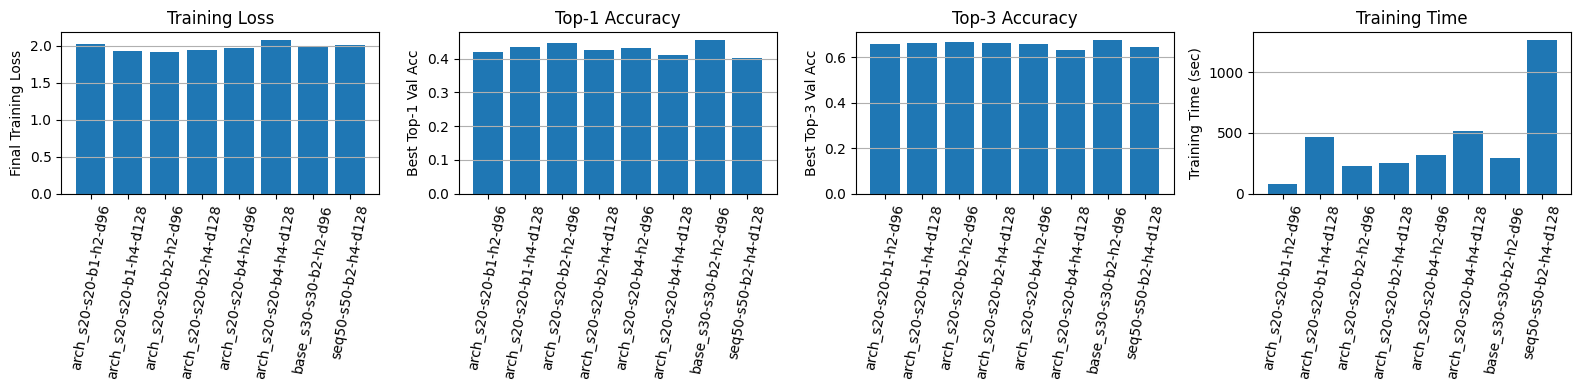

In [8]:
plt.figure(figsize=(16,4))
labels = results_df['name'] + '-s' + results_df['seq_length'].astype(str) + '-b' + results_df['num_layers'].astype(str) + '-h' + results_df['nhead'].astype(str) + '-d' + results_df['hidden_size'].astype(str)

plt.subplot(1,4,1)
plt.bar(range(len(results_df)), results_df['train_loss'])
plt.ylabel('Final Training Loss')
plt.title('Training Loss')
plt.grid(axis='y')

plt.subplot(1,4,2)
plt.bar(range(len(results_df)), results_df['best_val_accuracy'])
plt.ylabel('Best Top-1 Val Acc')
plt.title('Top-1 Accuracy')
plt.grid(axis='y')

plt.subplot(1,4,3)
plt.bar(range(len(results_df)), results_df['best_val_top3_accuracy'])
plt.ylabel('Best Top-3 Val Acc')
plt.title('Top-3 Accuracy')
plt.grid(axis='y')

plt.subplot(1,4,4)
plt.bar(range(len(results_df)), results_df['training_time_sec'])
plt.ylabel('Training Time (sec)')
plt.title('Training Time')
plt.grid(axis='y')

for ax in plt.gcf().axes:
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(labels, rotation=80)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem2_transformer_summary.png'), dpi=200, bbox_inches='tight')
plt.show()

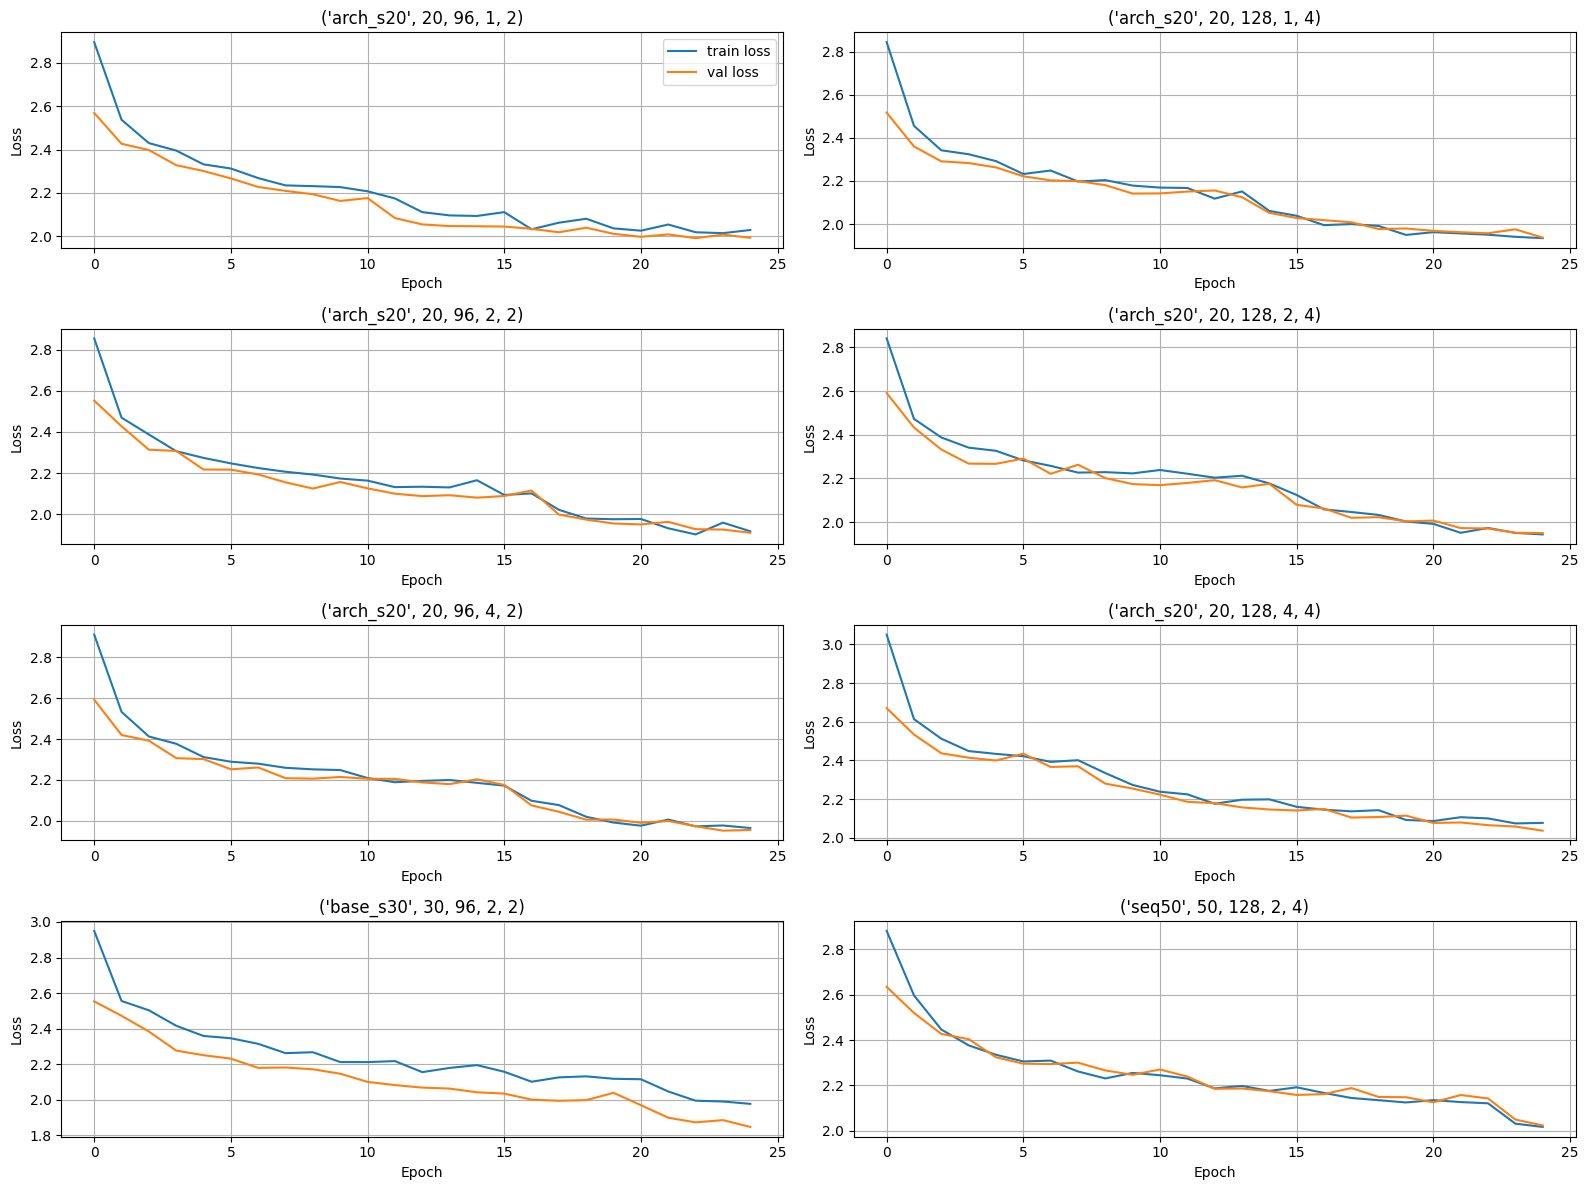

In [9]:
plt.figure(figsize=(16,12))
plot_num = 1
rows = math.ceil(len(history) / 2)
for key, curves in history.items():
    train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs = curves
    plt.subplot(rows, 2, plot_num)
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.title(str(key))
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    if plot_num == 1:
        plt.legend()
    plot_num += 1

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem2_transformer_loss_curves.png'), dpi=200, bbox_inches='tight')
plt.show()


In [10]:
# Compare with Homework 2 LSTM/GRU Tiny Shakespeare results.
hw2_path = os.path.join('..', 'Homework_2', 'Results_Problem_2', 'problem2_results.csv')
if os.path.exists(hw2_path):
    hw2_df = pd.read_csv(hw2_path)
    hw2_compare = hw2_df.copy()
    hw2_compare['nhead'] = ''
    hw2_compare['source'] = 'Homework 2 RNN based'

    transformer_compare = results_df.copy()
    transformer_compare['source'] = 'Homework 4 Transformer'

    keep_cols = ['source', 'model_type', 'name', 'seq_length', 'hidden_size', 'num_layers', 'nhead',
                 'train_loss', 'val_loss', 'best_val_accuracy', 'best_val_top3_accuracy', 'best_val_top5_accuracy',
                 'val_perplexity', 'training_time_sec', 'params', 'model_size_MB', 'rough_complexity']
    compare_df = pd.concat([hw2_compare[keep_cols], transformer_compare[keep_cols]], ignore_index=True)
    compare_df.to_csv(os.path.join(results_folder, 'problem2_transformer_vs_homework2_rnn.csv'), index=False)
    print(compare_df.to_string(index=False))
else:
    print('Homework 2 comparison file was not found:', hw2_path)

                source  model_type         name  seq_length  hidden_size  num_layers nhead  train_loss  val_loss  best_val_accuracy  best_val_top3_accuracy  best_val_top5_accuracy  val_perplexity  training_time_sec  params  model_size_MB  rough_complexity
  Homework 2 RNN based        LSTM         base          20          128           1          1.520821  1.564615           0.527734                0.746680                0.833854        4.780836         193.367145  164542       0.627678           2621440
  Homework 2 RNN based         GRU         base          20          128           1          1.541505  1.587946           0.526237                0.739583                0.824935        4.893685         471.892355  131518       0.501701           1966080
  Homework 2 RNN based        LSTM         base          30          128           1          1.524548  1.580193           0.525326                0.745052                0.832747        4.855894         238.550900  164542       0.6

In [11]:
def generate_text(model, start_text='To be, or not to be', seq_length=30, generate_len=300, temperature=0.8, top_k=5):
    model.eval()
    generated = start_text
    infer_start = time.time()
    with torch.no_grad():
        for i in range(generate_len):
            current = generated[-seq_length:]
            x = [char_to_int.get(ch, char_to_int[' ']) for ch in current]
            if len(x) < seq_length:
                x = [char_to_int[' ']] * (seq_length - len(x)) + x
            x = torch.tensor(x, dtype=torch.long).unsqueeze(0).to(device)
            out = model(x) / temperature

            # Top-k sampling usually looks better than pure argmax for generated Shakespeare text.
            values, indices = torch.topk(out, k=min(top_k, out.size(1)), dim=1)
            probs = torch.softmax(values, dim=1)
            pick = torch.multinomial(probs, num_samples=1).item()
            pred = indices[0, pick].item()
            generated += int_to_char[pred]
    return generated, time.time() - infer_start


best_row = results_df.sort_values('best_val_top3_accuracy', ascending=False).iloc[0]
best_key = (best_row['name'], int(best_row['seq_length']), int(best_row['hidden_size']), int(best_row['num_layers']), int(best_row['nhead']))
output_text, inference_time = generate_text(trained_models[best_key], seq_length=int(best_row['seq_length']))

print('Best Transformer key by top-3 validation accuracy:', best_key)
print('Top-1:', best_row['best_val_accuracy'], 'Top-3:', best_row['best_val_top3_accuracy'], 'Top-5:', best_row['best_val_top5_accuracy'])
print('Inference time:', inference_time)
print(output_text)

generated_rows = []
for key, model in trained_models.items():
    out_text, inf_time = generate_text(model, seq_length=key[1], generate_len=200)
    generated_rows.append({'key': str(key), 'inference_time_sec': inf_time, 'output_sequence': out_text})

generated_df = pd.DataFrame(generated_rows)
generated_df.to_csv(os.path.join(results_folder, 'problem2_transformer_generated_outputs.csv'), index=False)
generated_df

Best Transformer key by top-3 validation accuracy: ('base_s30', 30, 96, 2, 2)
Top-1: 0.455078125 Top-3: 0.675 Top-5: 0.788671875
Inference time: 0.4008646011352539
To be, or not to bet the them and with
The werven and hell.

Seces, the the mee and the mears the and warted the martter
The the all the to and the to shall ande sond hear he the whe thath the and to the thand the aritind they
To the a tor the theme their theis
The hall and he the a and the mee telve me the my they th


,key,inference_time_sec,output_sequence
0,"('arch_s20', 20, 96, 1, 2)",0.155652,"To be, or not to be well the whave shin his th..."
1,"('arch_s20', 20, 128, 1, 4)",0.188203,"To be, or not to be than ta mase the sin to th..."
2,"('arch_s20', 20, 96, 2, 2)",0.233407,"To be, or not to be come tan the wath her that..."
3,"('arch_s20', 20, 128, 2, 4)",0.263597,"To be, or not to bere to the sine to here the ..."
4,"('arch_s20', 20, 96, 4, 2)",0.396426,"To be, or not to be had and to shall the are a..."
5,"('arch_s20', 20, 128, 4, 4)",0.677850,"To be, or not to be the tound thate ole at and..."
6,"('base_s30', 30, 96, 2, 2)",0.308737,"To be, or not to be and they thee the tand tel..."
7,"('seq50', 50, 128, 2, 4)",0.493246,"To be, or not to bearet hound how the warde to..."
